**Name: Rishi Raj Phadale**  
**Roll No.: 23102C0070**  

## R Programming Assignment 5: Social Network Analysis with R



### 1. Install required package
One-line explanation: installs `igraph`, the core R package used for building, analyzing and visualizing networks.

In [1]:
# Install igraph (only needs to run once per Colab session)
install.packages("igraph", quiet = TRUE)


### 2. Load required libraries
One-line explanation: loads `igraph` for network analysis and base R plotting for visualizations.

In [2]:
library(igraph)
options(repr.plot.width = 8, repr.plot.height = 6)  # nicer plot size in Colab



Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## 3. Build small toy networks
One-line explanation: create a simple undirected graph to understand how `igraph` represents nodes and edges.

Warning message:
“`graph()` was deprecated in igraph 2.1.0.
ℹ Please use `make_graph()` instead.”


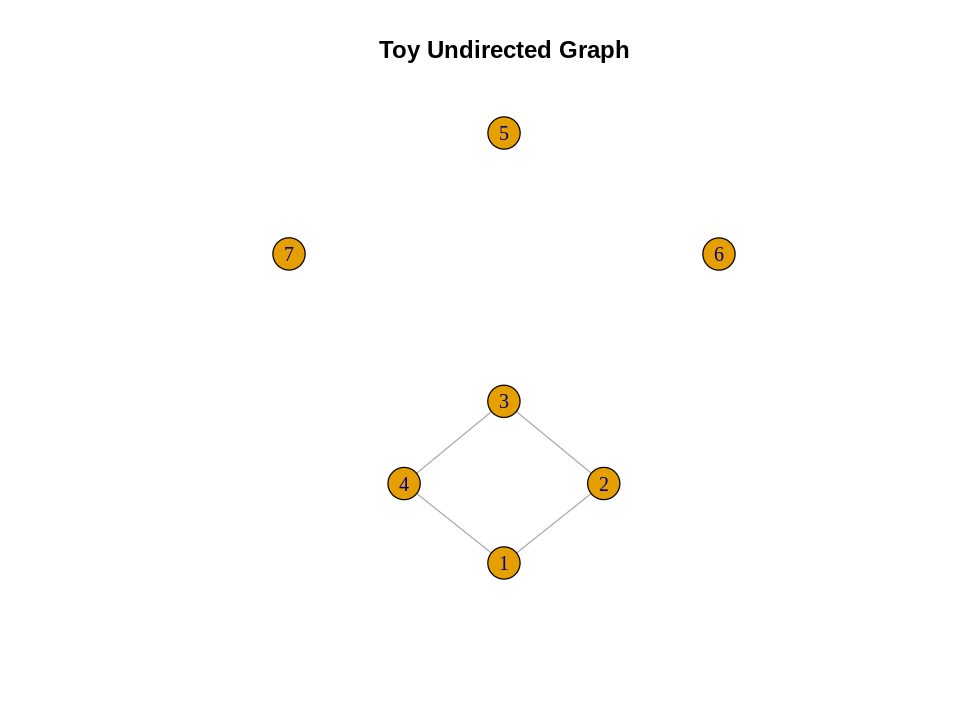

In [3]:
# Undirected toy graph: 4 nodes in a cycle, 7 vertices total (3 isolated)
g <- graph(c(1,2, 2,3, 3,4, 4,1), directed = FALSE, n = 7)
plot(g, main = "Toy Undirected Graph")


One-line explanation: create a small directed graph with named people to represent "who follows/knows whom".

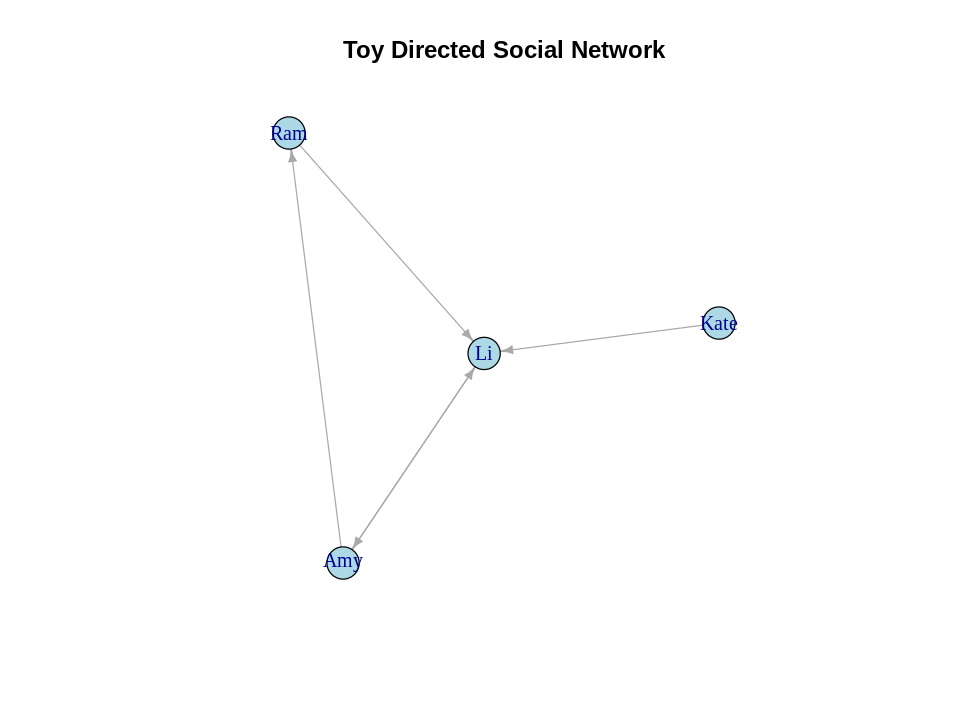

In [4]:
# Directed toy graph using named vertices (a mini social network)
g1 <- graph(c("Amy","Ram", "Ram","Li", "Li","Amy",
              "Amy","Li", "Kate","Li"), directed = TRUE)
plot(g1, main = "Toy Directed Social Network",
     vertex.color = "lightblue", edge.arrow.size = 0.6)


## 4. Basic network measures on the toy graph
One-line explanation: `degree()` counts how many connections each node has (total, incoming, outgoing).

In [5]:
degree(g1, mode = 'all')   # total connections per node
degree(g1, mode = 'in')    # who is followed the most
degree(g1, mode = 'out')   # who follows the most people


Amy  Ram   Li Kate 
   3    2    4    1

Amy  Ram   Li Kate 
   1    1    3    0

Amy  Ram   Li Kate 
   2    1    1    1

One-line explanation: `diameter()` gives the longest shortest-path in the network, i.e. how "spread out" the network is.

In [6]:
diameter(g1, directed = FALSE, weights = NA)


[1] 2

One-line explanation: `edge_density()` measures how complete the network is (fraction of all possible edges that actually exist).

In [7]:
edge_density(g1, loops = FALSE)
ecount(g1) / (vcount(g1) * (vcount(g1) - 1))  # manual verification of density


[1] 0.4166667

[1] 0.4166667

One-line explanation: `reciprocity()` shows what fraction of directed relationships are returned (mutual) connections.

In [8]:
reciprocity(g1)


[1] 0.4

One-line explanation: `closeness()` measures how quickly a node can reach all other nodes in the network.

In [9]:
closeness(g1, mode = 'all', weights = NA)


Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

One-line explanation: `betweenness()` measures how often a node lies on the shortest path between other nodes (a bridge/broker score).

In [10]:
betweenness(g1, directed = TRUE, weights = NA)
edge_betweenness(g1, directed = TRUE, weights = NA)


Amy  Ram   Li Kate 
   2    0    3    0

[1] 3 2 5 1 3

### 4.1 Enhancement — extra structural measures
One-line explanation: `transitivity()` (clustering coefficient) shows how likely a node's neighbors are also connected to each other, and `assortativity_degree()` shows if high-degree nodes tend to connect to other high-degree nodes.

In [11]:
transitivity(g1, type = "global")
assortativity_degree(g1, directed = TRUE)


[1] 0.6

[1] -0.1666667

## 5. Import the real network dataset
One-line explanation: reads the edge list (source–target pairs) used in the tutorial directly from GitHub.

In [12]:
data <- read.csv('https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv', header = TRUE)
head(data)
str(data)


,first,second,grade,spec
,<chr>,<chr>,<int>,<chr>
1,AA,DD,6,Y
2,AB,DD,6,R
3,AF,BA,6,Q
4,DD,DA,6,Q
5,CD,EC,6,X
6,DD,CE,6,Y


'data.frame':	290 obs. of  4 variables:
 $ first : chr  "AA" "AB" "AF" "DD" ...
 $ second: chr  "DD" "DD" "BA" "DA" ...
 $ grade : int  6 6 6 6 6 6 6 6 6 6 ...
 $ spec  : chr  "Y" "R" "Q" "Q" ...


One-line explanation: keeps only the two relationship columns and builds an `igraph` object (`net`) from the edge list.

In [13]:
y <- data.frame(data$first, data$second)
net <- graph.data.frame(y, directed = TRUE)

V(net)$label  <- V(net)$name
V(net)$degree <- degree(net)

cat("Number of nodes (people):", vcount(net), "\n")
cat("Number of edges (relationships):", ecount(net), "\n")


Warning message:
“`graph.data.frame()` was deprecated in igraph 2.0.0.
ℹ Please use `graph_from_data_frame()` instead.”


Number of nodes (people): 52 
Number of edges (relationships): 290 


## 6. Degree distribution
One-line explanation: a histogram of node degrees shows whether most people have few connections while a few are highly connected (typical of social networks).

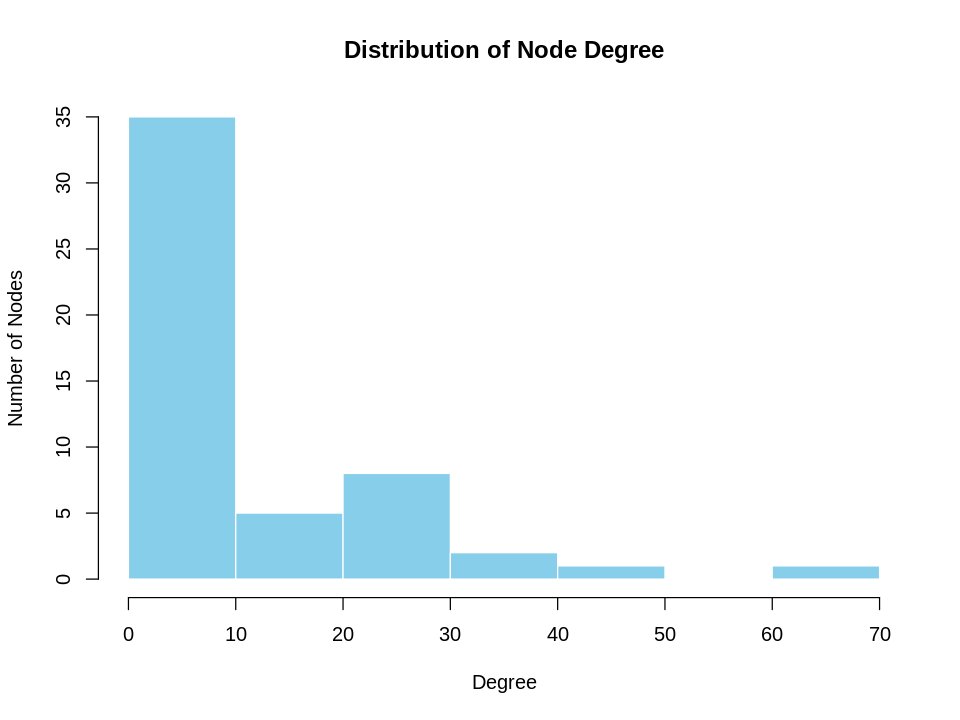

In [14]:
hist(V(net)$degree,
     col = "skyblue", border = "white",
     main = "Distribution of Node Degree",
     xlab = "Degree", ylab = "Number of Nodes")


### 6.1 Enhancement — summary statistics table
One-line explanation: prints min/mean/median/max degree so the distribution above is backed by concrete numbers.

In [15]:
summary(V(net)$degree)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    1.00    6.50   11.15   18.50   62.00 

## 7. Basic network diagram
One-line explanation: the default `plot()` on `net` gives a first quick look at the overall network shape.

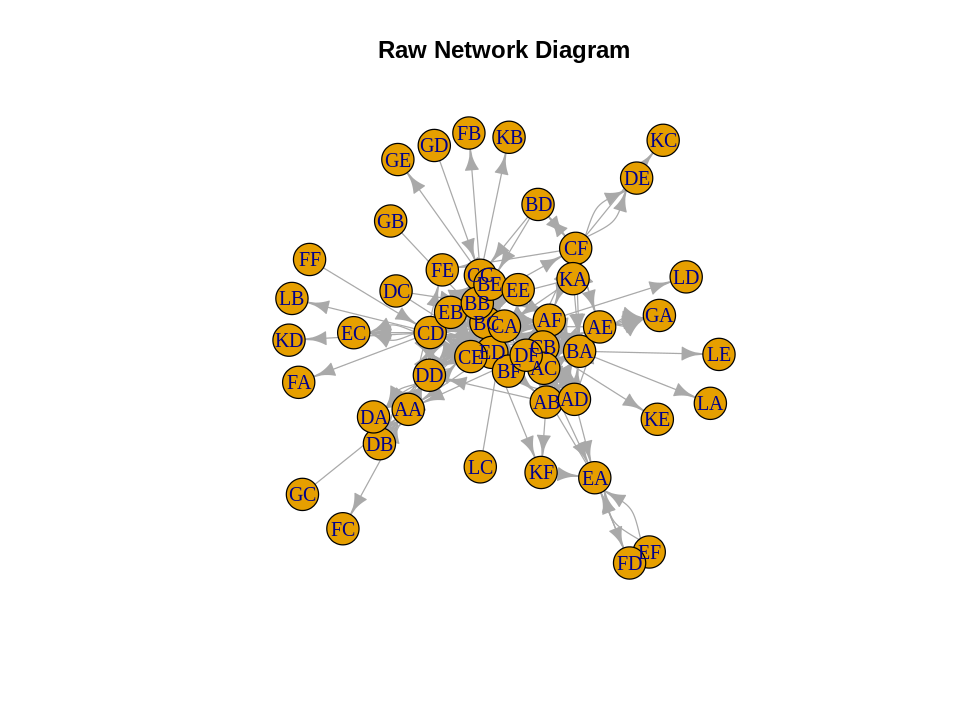

In [16]:
plot(net, main = "Raw Network Diagram")


## 8. Enhanced visualization — size & color by degree
One-line explanation: node color varies (`rainbow`) and node size scales with degree, so highly-connected people visually stand out.

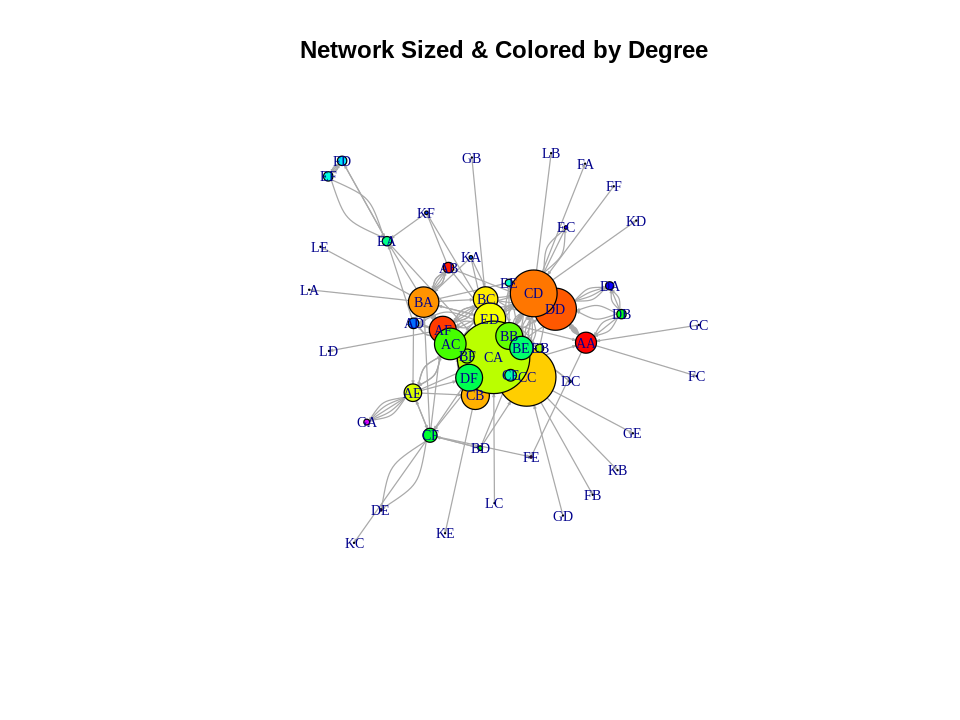

In [17]:
plot(net,
     vertex.color = rainbow(vcount(net)),
     vertex.size = V(net)$degree * 0.6,
     vertex.label.cex = 0.7,
     edge.arrow.size = 0.15,
     layout = layout.fruchterman.reingold,
     main = "Network Sized & Colored by Degree")


### 8.1 Enhancement — degree as a color gradient (heat-map style)
One-line explanation: instead of random rainbow colors, nodes are shaded from light to dark based on their actual degree value, making high-degree "hubs" immediately obvious.

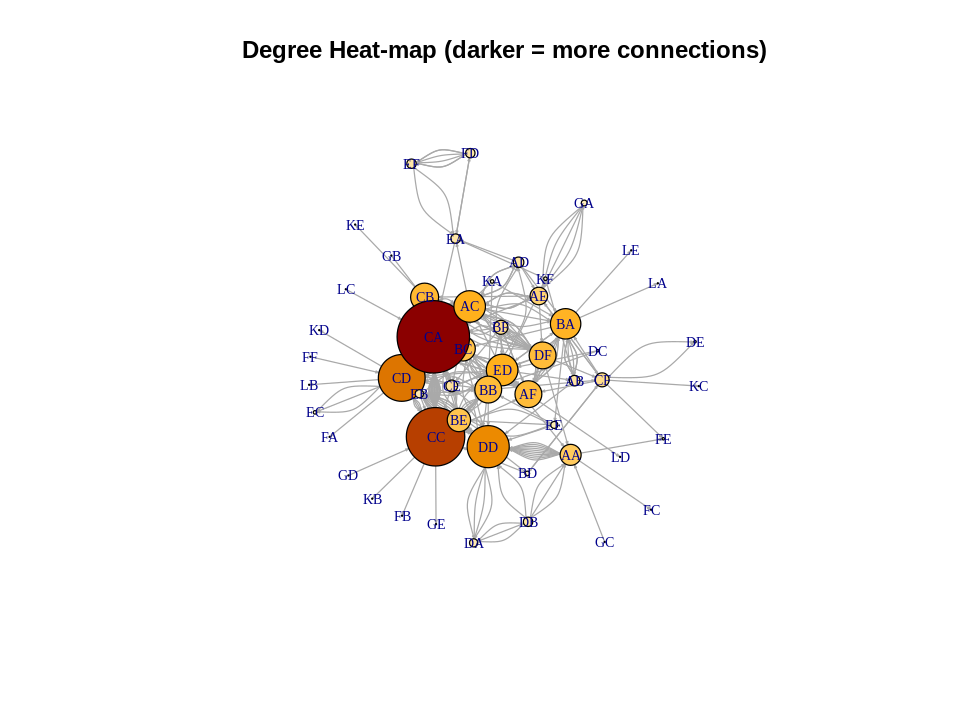

In [18]:
deg <- V(net)$degree
color_ramp <- colorRampPalette(c("lightyellow", "orange", "darkred"))(max(deg) + 1)
V(net)$color <- color_ramp[deg + 1]

plot(net,
     vertex.size = deg * 0.6,
     vertex.label.cex = 0.7,
     edge.arrow.size = 0.15,
     layout = layout.kamada.kawai,
     main = "Degree Heat-map (darker = more connections)")


## 9. Hub and Authority scores
One-line explanation: `hub_score()` finds nodes that point to many others (good "connectors"), while `authority.score()` finds nodes that are pointed to by many hubs (trusted / popular nodes).

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority.score()` was deprecated in igraph 2.0.0.
ℹ Please use `hits_scores()` instead.”


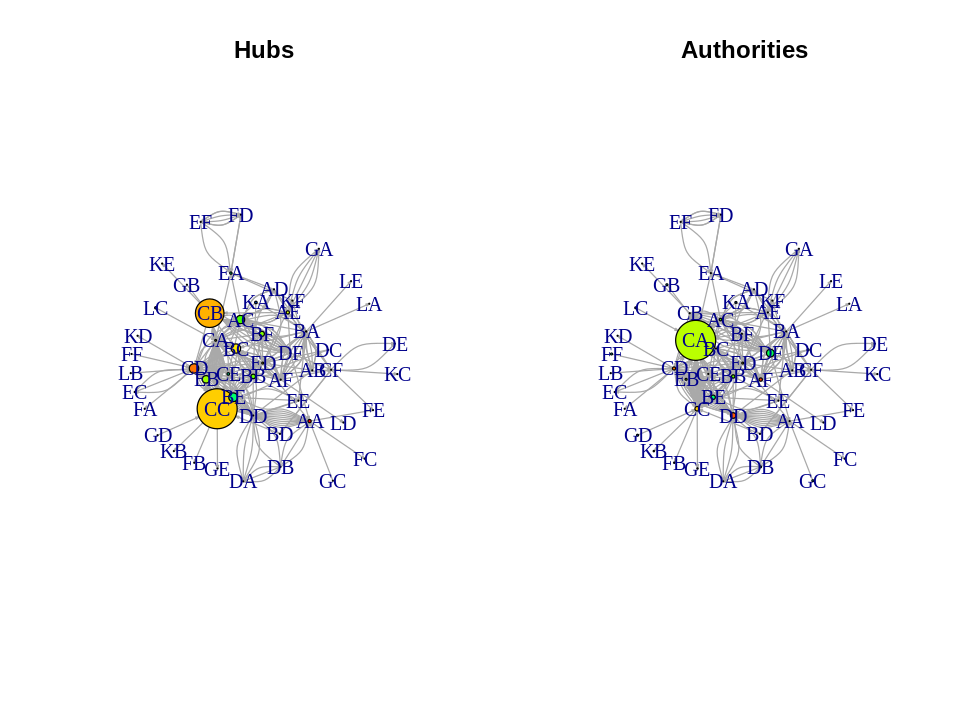

In [19]:
hs <- hub_score(net)$vector
as_ <- authority.score(net)$vector

par(mfrow = c(1,2))
set.seed(123)
plot(net, vertex.size = hs * 30, main = 'Hubs',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size = 0.1, layout = layout.kamada.kawai)
plot(net, vertex.size = as_ * 30, main = 'Authorities',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size = 0.1, layout = layout.kamada.kawai)
par(mfrow = c(1,1))


## 10. Enhancement — combined centrality table (identify influential nodes)
One-line explanation: combines degree, closeness, betweenness, hub and authority scores into one table and ranks people to clearly identify the most influential nodes in the network.

In [20]:
centrality_df <- data.frame(
  name        = V(net)$name,
  degree      = degree(net, mode = 'all'),
  in_degree   = degree(net, mode = 'in'),
  out_degree  = degree(net, mode = 'out'),
  closeness   = round(closeness(net, mode = 'all', weights = NA), 4),
  betweenness = round(betweenness(net, directed = TRUE, weights = NA), 2),
  hub_score   = round(hs, 3),
  authority   = round(as_, 3)
)

# Top 5 most influential nodes overall (by degree)
centrality_df[order(-centrality_df$degree), ][1:5, ]


,name,degree,in_degree,out_degree,closeness,betweenness,hub_score,authority
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CA,CA,62,50,12,0.0100,292.16,0.045,1.000
CC,CC,50,25,25,0.0097,225.27,1.000,0.112
CD,CD,40,15,25,0.0101,375.99,0.235,0.079
DD,DD,36,28,8,0.0088,162.99,0.013,0.141
ED,ED,27,10,17,0.0106,343.02,0.049,0.048


One-line explanation: separately ranks the top hubs (best connectors) and top authorities (most "looked up to" nodes) for a clearer interpretation.

In [21]:
cat("Top 3 Hubs:\n")
print(centrality_df[order(-centrality_df$hub_score), c('name','hub_score')][1:3, ])

cat("\nTop 3 Authorities:\n")
print(centrality_df[order(-centrality_df$authority), c('name','authority')][1:3, ])


Top 3 Hubs:
   name hub_score
CC   CC     1.000
CB   CB     0.715
CD   CD     0.235

Top 3 Authorities:
   name authority
CA   CA     1.000
DF   DF     0.193
DD   DD     0.141


## 11. Community detection (edge-betweenness)
One-line explanation: converts the network to undirected and uses `cluster_edge_betweenness()` to detect tightly-knit sub-groups ("communities") of people.

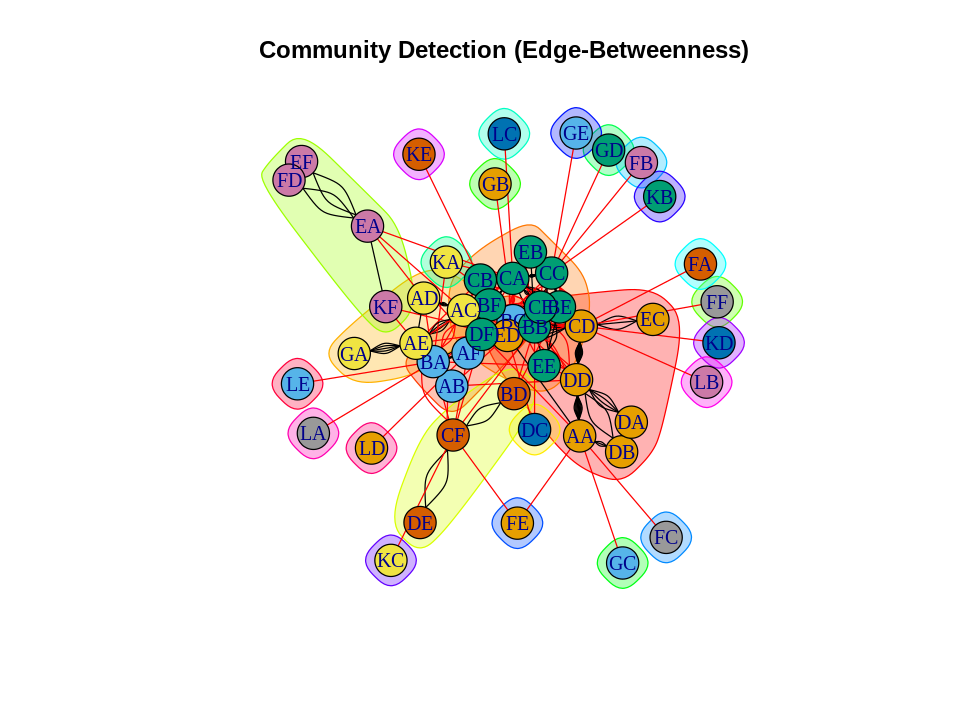

In [22]:
net_u <- graph.data.frame(y, directed = FALSE)
cnet <- cluster_edge_betweenness(net_u)
plot(cnet, net_u, main = "Community Detection (Edge-Betweenness)")


### 11.1 Enhancement — modularity score & community sizes
One-line explanation: `modularity()` scores how well-separated the detected communities are (closer to 1 = stronger community structure), and the table shows how many people are in each community.

In [23]:
cat("Number of communities found:", length(cnet), "\n")
cat("Modularity score:", round(modularity(cnet), 4), "\n\n")
table(membership(cnet))


Number of communities found: 26 
Modularity score: 0.3514 




 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 
 7  4 10  4  1  3  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 

### 11.2 Enhancement — compare with Louvain community detection
One-line explanation: runs a second, faster community-detection algorithm (`cluster_louvain`) and compares its modularity to edge-betweenness, showing whether both methods agree on the network's structure.

Edge-Betweenness -> communities: 26  | modularity: 0.3514 
Louvain          -> communities: 6  | modularity: 0.4347 


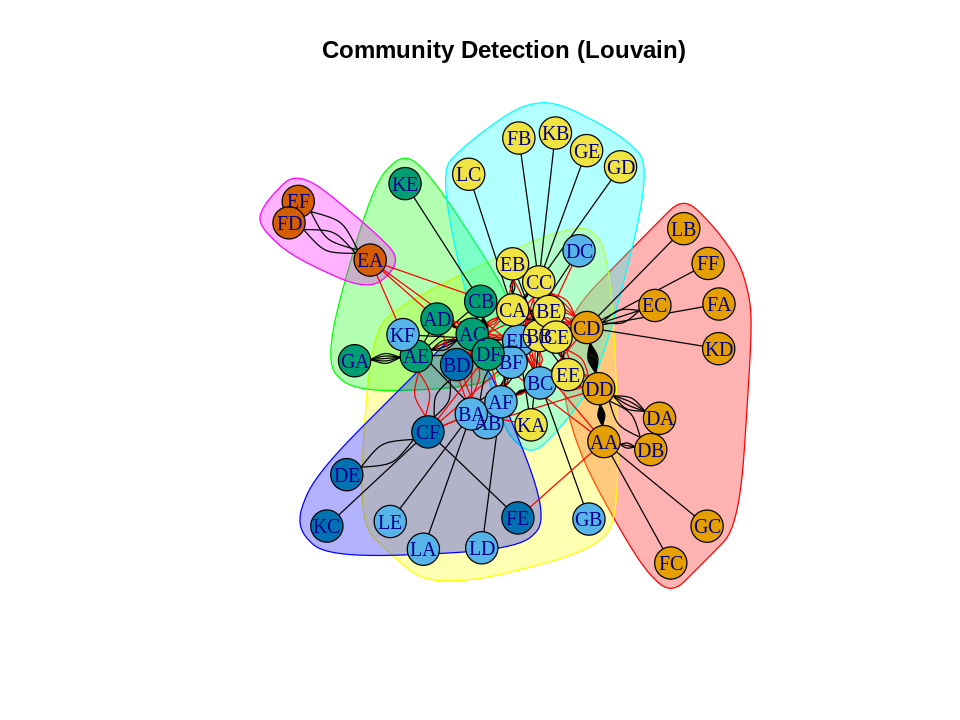

In [24]:
cnet_louvain <- cluster_louvain(net_u)

cat("Edge-Betweenness -> communities:", length(cnet),
    " | modularity:", round(modularity(cnet), 4), "\n")
cat("Louvain          -> communities:", length(cnet_louvain),
    " | modularity:", round(modularity(cnet_louvain), 4), "\n")

plot(cnet_louvain, net_u, main = "Community Detection (Louvain)")


## 12. Save outputs (script, data, and results)
One-line explanation: saves the centrality table as a CSV and the key visualizations as PNG files so they can be submitted as lab deliverables.

In [25]:
dir.create("outputs", showWarnings = FALSE)

write.csv(centrality_df, "outputs/centrality_measures.csv", row.names = FALSE)

png("outputs/network_degree_plot.png", width = 900, height = 700)
plot(net, vertex.color = rainbow(vcount(net)), vertex.size = V(net)$degree*0.6,
     vertex.label.cex = 0.7, edge.arrow.size = 0.15,
     layout = layout.fruchterman.reingold, main = "Network Sized & Colored by Degree")
dev.off()

png("outputs/community_plot.png", width = 900, height = 700)
plot(cnet, net_u, main = "Community Detection (Edge-Betweenness)")
dev.off()

list.files("outputs")


agg_record_53f4a8886be 
                     2

agg_record_53f4a8886be 
                     2

[1] "centrality_measures.csv" "community_plot.png"     
[3] "network_degree_plot.png"

One-line explanation: downloads the saved output files from the Colab session to your local machine (skip this cell if not using Colab, or if you'll browse the files panel manually).

In [26]:
# Uncomment to download in Google Colab (requires the reticulate/Python 'files' helper,
# so this is typically run from a Python cell instead — see note below).
# In R-only Colab runtimes, use the Files pane on the left to right-click > Download
# on the files inside the 'outputs' folder.
list.files("outputs", full.names = TRUE)


[1] "outputs/centrality_measures.csv" "outputs/community_plot.png"     
[3] "outputs/network_degree_plot.png"

## 13. Interpretation of Results

- **Degree distribution:** The histogram shows most nodes have a low degree while a small number of nodes have noticeably higher degree — a common "hub-and-spoke" pattern seen in real social networks.
- **Density & reciprocity (toy network):** A low edge density indicates the network is far from fully connected; reciprocity tells us what proportion of relationships are mutual rather than one-directional.
- **Centrality table:** Nodes with the highest **degree** and **betweenness** act as the network's most connected people and its key "brokers" who link otherwise separate parts of the network. Nodes with the highest **closeness** can reach everyone else fastest.
- **Hubs vs Authorities:** High **hub score** nodes actively point to many others (they "reach out"), while high **authority score** nodes are the ones frequently pointed to (they are "sought after"). Comparing both highlights different types of influence in the network.
- **Community detection:** The edge-betweenness and Louvain algorithms both partition the network into sub-groups of closely related nodes. A higher **modularity** score (closer to 1) indicates a stronger, more clearly separated community structure; similar community counts/modularity from both algorithms increases confidence in the grouping.
- **Overall:** Combining degree, centrality, hub/authority, and community results gives a fuller picture of *who* is influential and *how* — some nodes matter because they are highly connected, others because they bridge separate communities, and others because they are trusted reference points (authorities).
